# EDA Adapter - Analyse des Bases de Données Time-Series
Notebook d'Exploratory Data Analysis (EDA) pour comprendre les données disponibles dans le dossier 'data'.

## Section 1: Importer les bibliothèques nécessaires
Importation de pandas, numpy, matplotlib, seaborn et autres outils pour l'analyse et la visualisation des données.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration des styles de visualisation
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Bibliothèques importées avec succès!")

✓ Bibliothèques importées avec succès!


## Section 2: Lister les fichiers dans le dossier data
Affichage de tous les fichiers disponibles dans le dossier 'data'.

In [2]:
# Définir le chemin du dossier data
data_folder = Path('data')

# Lister tous les fichiers
files = sorted([f for f in data_folder.iterdir() if f.is_file()])

print(f"📁 Nombre de fichiers trouvés: {len(files)}\n")
print("Fichiers disponibles:")
for i, file in enumerate(files, 1):
    file_size = file.stat().st_size / (1024 * 1024)  # Taille en MB
    print(f"  {i}. {file.name} ({file_size:.2f} MB)")

📁 Nombre de fichiers trouvés: 8

Fichiers disponibles:
  1. 52.csv (5.60 MB)
  2. I11.csv (5.70 MB)
  3. I113.csv (5.78 MB)
  4. I23.csv (5.71 MB)
  5. I32.csv (5.70 MB)
  6. I42.csv (5.71 MB)
  7. I43.csv (5.70 MB)
  8. I61.csv (5.74 MB)


## Section 3: Charger les bases de données
Chargement de chaque fichier CSV du dossier 'data' dans un dictionnaire de DataFrames.

In [3]:
# Charger tous les fichiers CSV (format InfluxDB annotated CSV)
# Les 3 premières lignes sont des métadonnées (#group, #datatype, #default)
dataframes = {}

for file in files:
    if file.suffix.lower() == '.csv':
        try:
            df = pd.read_csv(file, skiprows=3)
            # Convertir _time en datetime et _value en float
            if '_time' in df.columns:
                df['_time'] = pd.to_datetime(df['_time'])
            if '_value' in df.columns:
                df['_value'] = pd.to_numeric(df['_value'], errors='coerce')
            dataframes[file.stem] = df
            print(f"✓ {file.name}: {df.shape[0]} lignes x {df.shape[1]} colonnes")
        except Exception as e:
            print(f"✗ Erreur lors du chargement de {file.name}: {e}")

print(f"\n📊 Total: {len(dataframes)} fichiers chargés avec succès!")

✓ 52.csv: 53391 lignes x 11 colonnes
✓ I11.csv: 53433 lignes x 11 colonnes
✓ I113.csv: 53238 lignes x 11 colonnes
✓ I23.csv: 53489 lignes x 11 colonnes
✓ I32.csv: 53441 lignes x 11 colonnes
✓ I42.csv: 53424 lignes x 11 colonnes
✓ I43.csv: 53406 lignes x 11 colonnes
✓ I61.csv: 53332 lignes x 11 colonnes

📊 Total: 8 fichiers chargés avec succès!


## Section 4: Afficher les premières lignes de chaque base
Aperçu initial des 5 premières lignes de chaque DataFrame.

In [4]:
# Afficher les 5 premières lignes de chaque base
for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"📋 Base de données: {name}")
    print(f"{'='*60}")
    print(df.head())
    print()


📋 Base de données: 52
   Unnamed: 0  result  table                         _start  \
0         NaN     NaN      0  2026-03-10T09:36:24.03245343Z   
1         NaN     NaN      0  2026-03-10T09:36:24.03245343Z   
2         NaN     NaN      0  2026-03-10T09:36:24.03245343Z   
3         NaN     NaN      0  2026-03-10T09:36:24.03245343Z   
4         NaN     NaN      0  2026-03-10T09:36:24.03245343Z   

                           _stop                            _time  _value  \
0  2026-03-10T12:36:24.03245343Z 2026-03-10 09:36:24.225000+00:00   0.577   
1  2026-03-10T12:36:24.03245343Z 2026-03-10 09:36:24.425000+00:00   0.573   
2  2026-03-10T12:36:24.03245343Z 2026-03-10 09:36:24.625000+00:00   0.573   
3  2026-03-10T12:36:24.03245343Z 2026-03-10 09:36:24.825000+00:00   0.582   
4  2026-03-10T12:36:24.03245343Z 2026-03-10 09:36:25.025000+00:00   0.572   

  _field _measurement  did type  
0  value          I52    9    I  
1  value          I52    9    I  
2  value          I52    9    I  

## Section 5: Analyser les types de colonnes et les valeurs manquantes
Affichage des types de données et du nombre de valeurs manquantes pour chaque base.

In [5]:
# Analyser les types et les valeurs manquantes
for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"🔍 Analyse: {name}")
    print(f"{'='*60}")
    print("\nTypes de colonnes:")
    print(df.dtypes)
    
    print("\nValeurs manquantes:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ Aucune valeur manquante détectée")
    else:
        print(missing[missing > 0])
    
    print(f"\nDimensions: {df.shape[0]} lignes, {df.shape[1]} colonnes")


🔍 Analyse: 52

Types de colonnes:
Unnamed: 0                  float64
result                      float64
table                         int64
_start                          str
_stop                           str
_time           datetime64[us, UTC]
_value                      float64
_field                          str
_measurement                    str
did                           int64
type                            str
dtype: object

Valeurs manquantes:
Unnamed: 0    53391
result        53391
dtype: int64

Dimensions: 53391 lignes, 11 colonnes

🔍 Analyse: I11

Types de colonnes:
Unnamed: 0                  float64
result                      float64
table                         int64
_start                          str
_stop                           str
_time           datetime64[us, UTC]
_value                      float64
_field                          str
_measurement                    str
did                           int64
type                            str
dtype: obj

## Section 6: Statistiques descriptives sur chaque base
Statistiques descriptives des variables numériques à l'aide de describe().

In [6]:
# Statistiques descriptives pour chaque base
for name, df in dataframes.items():
    print(f"\n{'='*60}")
    print(f"📊 Statistiques descriptives: {name}")
    print(f"{'='*60}")
    
    # Colonnes numériques
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(df[numeric_cols].describe().T)
    else:
        print("Aucune colonne numérique trouvée")
    
    # Colonnes catégorielles
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print("\n--- Colonnes catégorielles ---")
        for col in categorical_cols:
            print(f"\n{col}:")
            print(df[col].value_counts())


📊 Statistiques descriptives: 52
              count     mean       std   min    25%    50%   75%    max
Unnamed: 0      0.0      NaN       NaN   NaN    NaN    NaN   NaN    NaN
result          0.0      NaN       NaN   NaN    NaN    NaN   NaN    NaN
table       53391.0  0.00000  0.000000  0.00  0.000  0.000  0.00  0.000
_value      53391.0  1.33393  0.655386  0.55  0.581  1.863  1.89  9.953
did         53391.0  9.00000  0.000000  9.00  9.000  9.000  9.00  9.000

--- Colonnes catégorielles ---

_start:
_start
2026-03-10T09:36:24.03245343Z    53391
Name: count, dtype: int64

_stop:
_stop
2026-03-10T12:36:24.03245343Z    53391
Name: count, dtype: int64

_field:
_field
value    53391
Name: count, dtype: int64

_measurement:
_measurement
I52    53391
Name: count, dtype: int64

type:
type
I    53391
Name: count, dtype: int64

📊 Statistiques descriptives: I11
              count      mean       std    min    25%    50%   75%   max
Unnamed: 0      0.0       NaN       NaN    NaN    NaN    NaN   

### 🔎 Interprétation — C'est quoi ces fichiers ? Que contiennent-ils ?

#### Réponse simple
**OUI, chaque fichier = 1 capteur de courant électrique (en Ampères).**

Chaque fichier CSV (52.csv, I11.csv, I113.csv, etc.) contient les **mesures d'un seul capteur** sur une durée d'environ **3 heures**, avec une mesure toutes les **~200 ms** (5 mesures par seconde), soit environ **53 000 points de mesure** par fichier.

#### Structure d'un fichier (colonnes)
Les données viennent d'une base **InfluxDB** (base de données pour séries temporelles). Voici le rôle de chaque colonne :

| Colonne | Rôle | Utile ? |
|---------|------|---------|
| `Unnamed: 0` | Colonne vide (artéfact du format InfluxDB) | ❌ Non |
| `result` | Toujours vide | ❌ Non |
| `table` | Toujours `0` (numéro de table InfluxDB) | ❌ Non |
| `_start` | Début de la fenêtre de requête (constant) | ❌ Non |
| `_stop` | Fin de la fenêtre de requête (constant) | ❌ Non |
| **`_time`** | **Horodatage de la mesure** (quand la mesure a été prise) | ✅ **OUI** |
| **`_value`** | **La valeur mesurée par le capteur** (courant en Ampères) | ✅ **OUI** |
| `_field` | Toujours `value` (nom du champ InfluxDB) | ❌ Non |
| **`_measurement`** | **Nom/identifiant du capteur** (ex: I11, I52, I113...) | ✅ **OUI** |
| **`did`** | **Device ID** — numéro de l'appareil/équipement | ✅ **OUI** |
| `type` | Toujours `I` (type de mesure = courant) | ⚠️ Info mais constant |

#### En résumé : seulement 3 colonnes utiles par fichier
Pour l'analyse, on a besoin uniquement de :
1. **`_time`** → quand ?
2. **`_value`** → combien d'Ampères ?
3. **`_measurement`** / **`did`** → quel capteur ?

#### Les 8 capteurs enregistrés

| Fichier | Capteur (`_measurement`) | Device (`did`) | Nb points | Durée | Échantillonnage |
|---------|--------------------------|----------------|-----------|-------|-----------------|
| 52.csv | I52 | 9 | 53 391 | ~3h | ~200 ms |
| I11.csv | I11 | 3 | 53 433 | ~3h | ~200 ms |
| I113.csv | I113 | 18 | 53 238 | ~3h | ~200 ms |
| I23.csv | I23 | 4 | 53 489 | ~3h | ~200 ms |
| I32.csv | I32 | 5 | 53 441 | ~3h | ~200 ms |
| I42.csv | I42 | 6 | 53 424 | ~3h | ~200 ms |
| I43.csv | I43 | 8 | 53 406 | ~3h | ~200 ms |
| I61.csv | I61 | 10 | 53 332 | ~3h | ~200 ms |

Tous les capteurs enregistrent le **10 mars 2026**, entre **~09h34 et ~12h40 UTC**.

## Section 7: Visualisation des distributions des variables
Création de graphiques (histogrammes et boxplots) pour visualiser les distributions des variables principales.

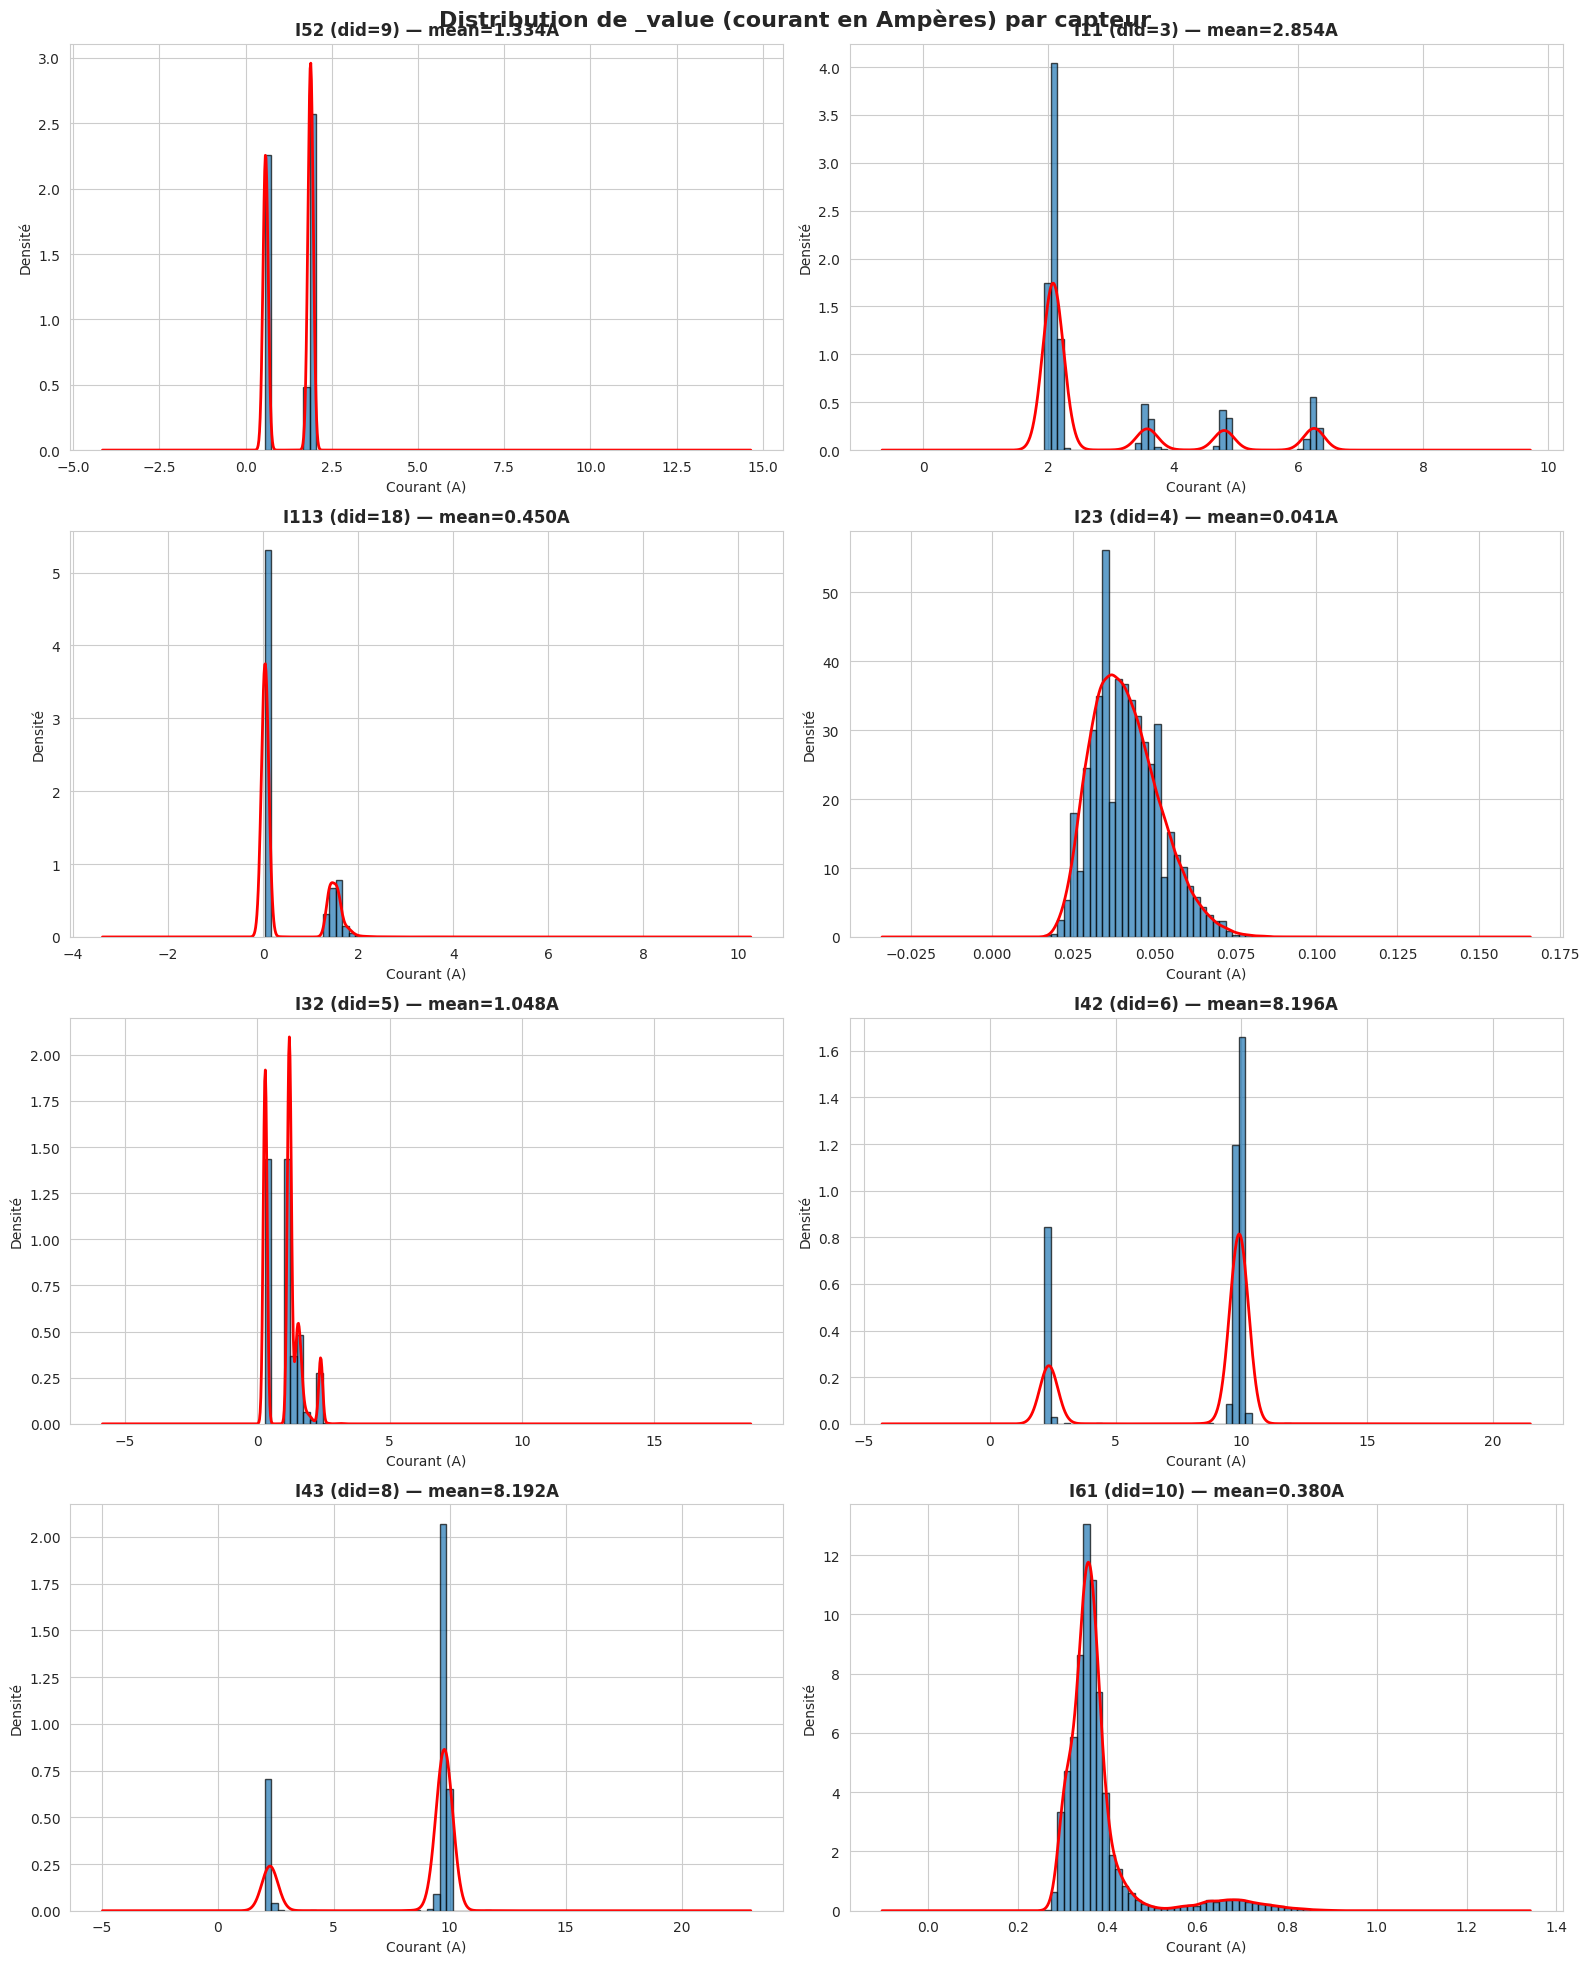

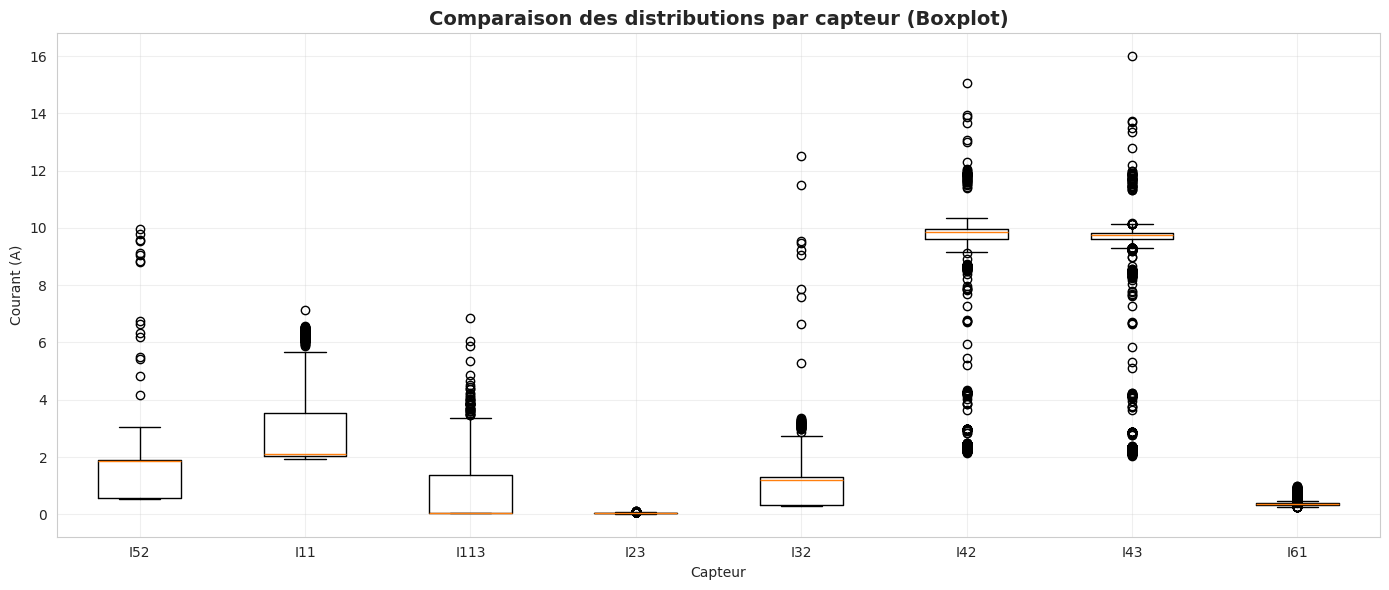

In [7]:
# Visualisation des distributions de _value pour chaque capteur
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Distribution de _value (courant en Ampères) par capteur', fontsize=16, fontweight='bold')

for idx, (name, df) in enumerate(dataframes.items()):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    measurement = df['_measurement'].iloc[0] if '_measurement' in df.columns else name
    
    # Histogramme avec KDE
    ax.hist(df['_value'].dropna(), bins=50, edgecolor='black', alpha=0.7, density=True)
    df['_value'].dropna().plot.kde(ax=ax, color='red', linewidth=2)
    ax.set_title(f'{measurement} (did={df["did"].iloc[0]}) — mean={df["_value"].mean():.3f}A', fontweight='bold')
    ax.set_xlabel('Courant (A)')
    ax.set_ylabel('Densité')

plt.tight_layout()
plt.show()

# Boxplots comparatifs
fig, ax = plt.subplots(figsize=(14, 6))
all_data = []
labels = []
for name, df in dataframes.items():
    measurement = df['_measurement'].iloc[0] if '_measurement' in df.columns else name
    all_data.append(df['_value'].dropna().values)
    labels.append(measurement)

ax.boxplot(all_data, labels=labels)
ax.set_title('Comparaison des distributions par capteur (Boxplot)', fontsize=14, fontweight='bold')
ax.set_ylabel('Courant (A)')
ax.set_xlabel('Capteur')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8: Analyse Time-Series
Visualisation des séries temporelles pour identifier les tendances, la saisonnalité et les anomalies potentielles.
- **8.1** — Tracé des séries temporelles avec moyenne mobile
- **8.2** — Détection des outliers par méthode IQR
- **8.3** — Comparaison de toutes les séries normalisées
- **8.4** — Résumé et interprétation

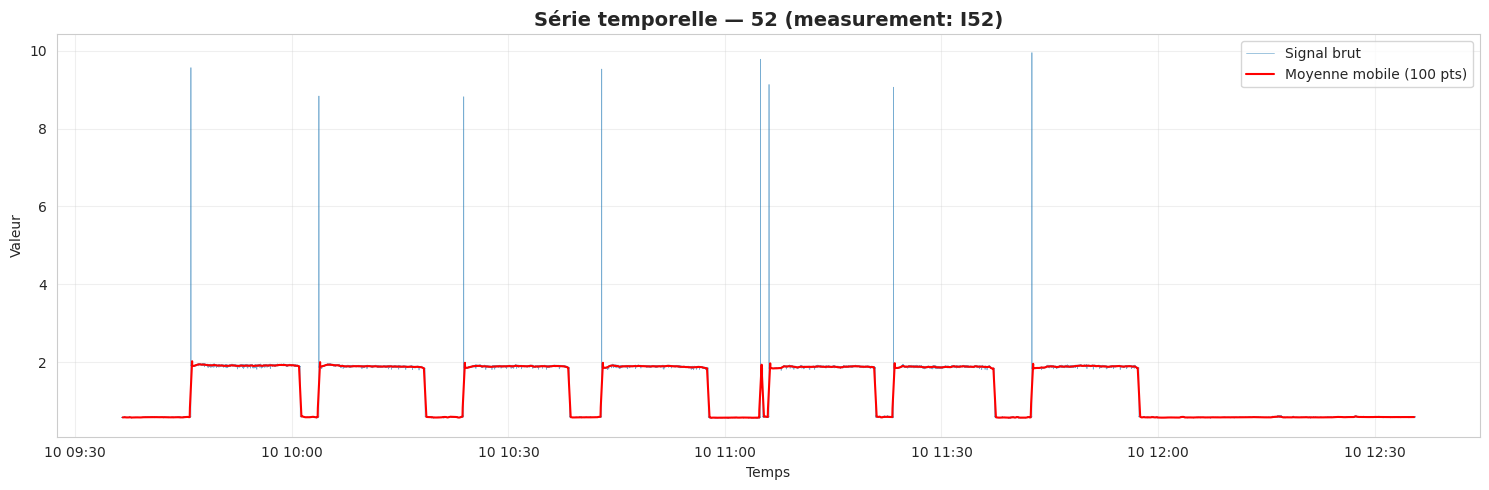

  📈 52: min=0.5500, max=9.9530, mean=1.3339, std=0.6554
  ⏱️  Période: 2026-03-10 09:36:24.225000+00:00 → 2026-03-10 12:35:39.025000+00:00
  📏 Nombre de points: 53391


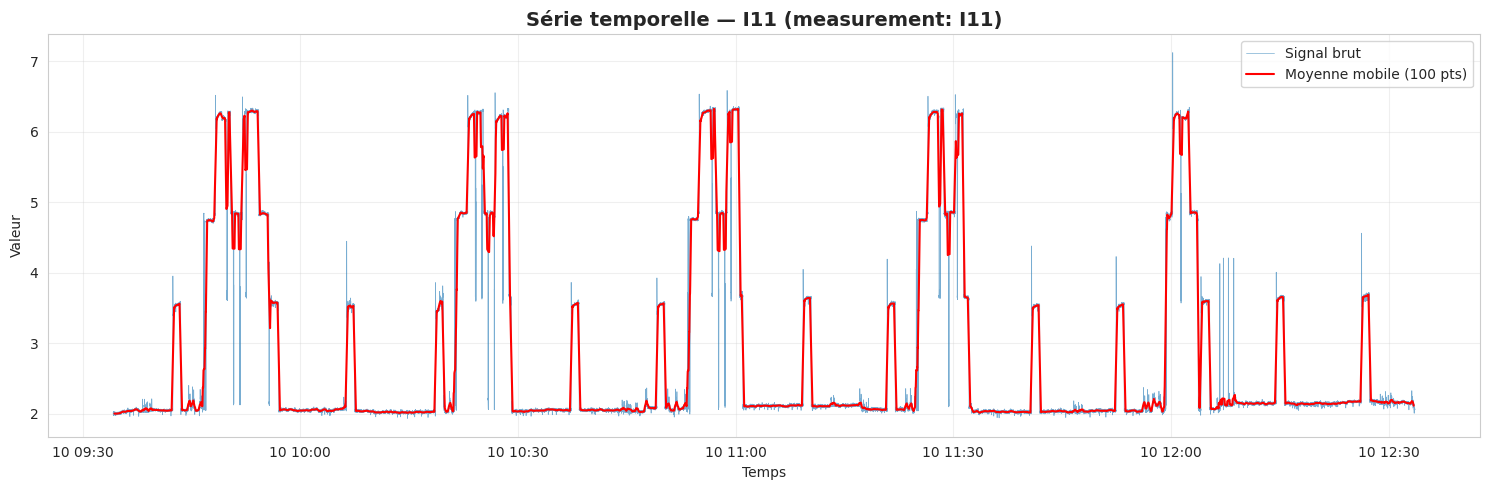

  📈 I11: min=1.9360, max=7.1200, mean=2.8537, std=1.3794
  ⏱️  Période: 2026-03-10 09:34:13.825000+00:00 → 2026-03-10 12:33:37.025000+00:00
  📏 Nombre de points: 53433


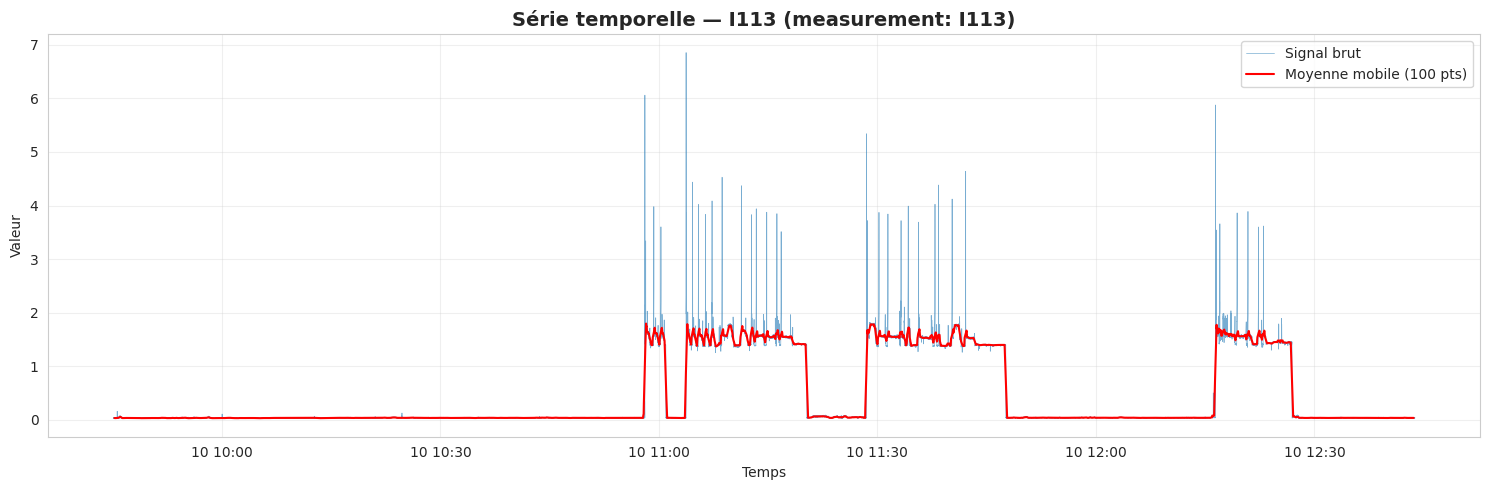

  📈 I113: min=0.0280, max=6.8530, mean=0.4501, std=0.6759
  ⏱️  Période: 2026-03-10 09:45:04.625000+00:00 → 2026-03-10 12:43:48.025000+00:00
  📏 Nombre de points: 53238


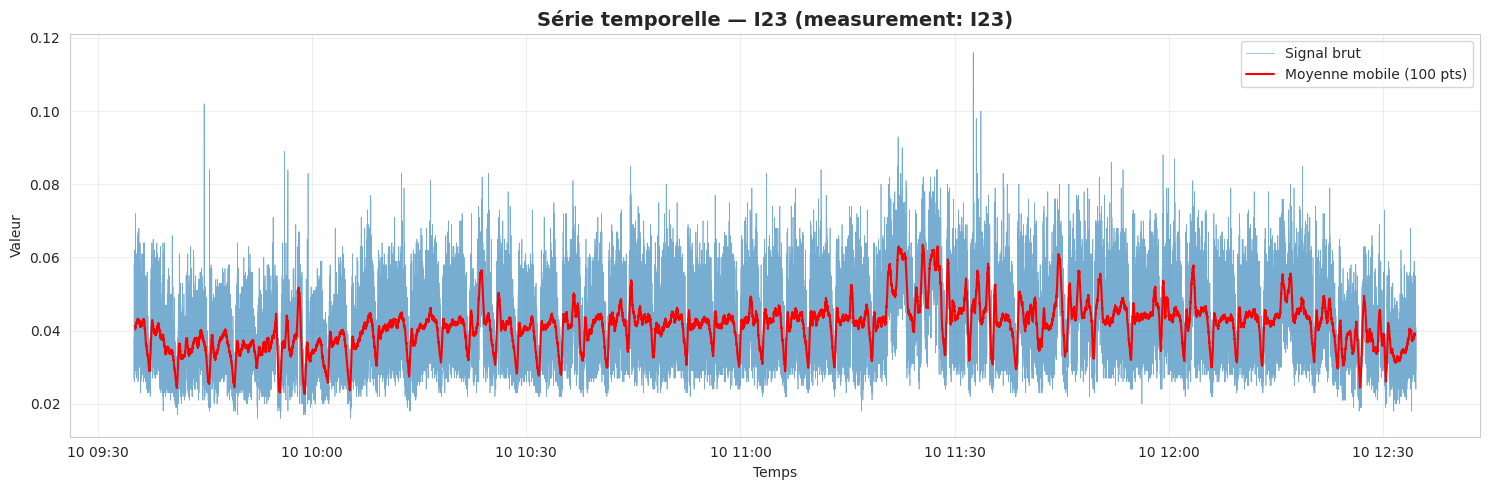

  📈 I23: min=0.0160, max=0.1160, mean=0.0413, std=0.0105
  ⏱️  Période: 2026-03-10 09:35:03.225000+00:00 → 2026-03-10 12:34:38.025000+00:00
  📏 Nombre de points: 53489


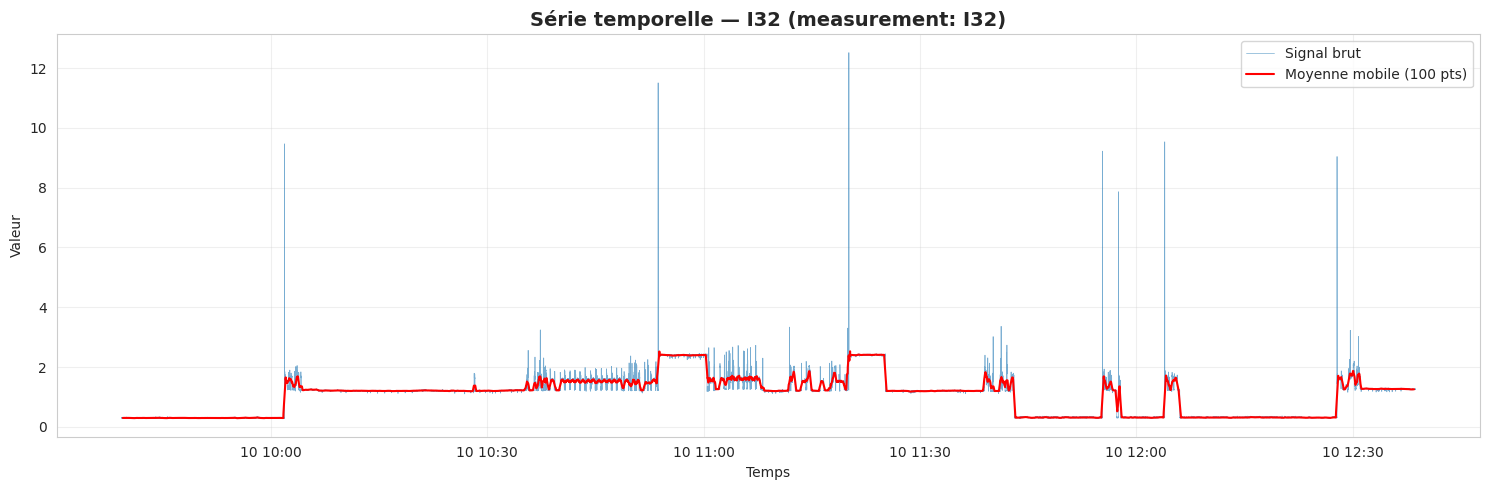

  📈 I32: min=0.2800, max=12.5170, mean=1.0480, std=0.6347
  ⏱️  Période: 2026-03-10 09:39:17.025000+00:00 → 2026-03-10 12:38:42.025000+00:00
  📏 Nombre de points: 53441


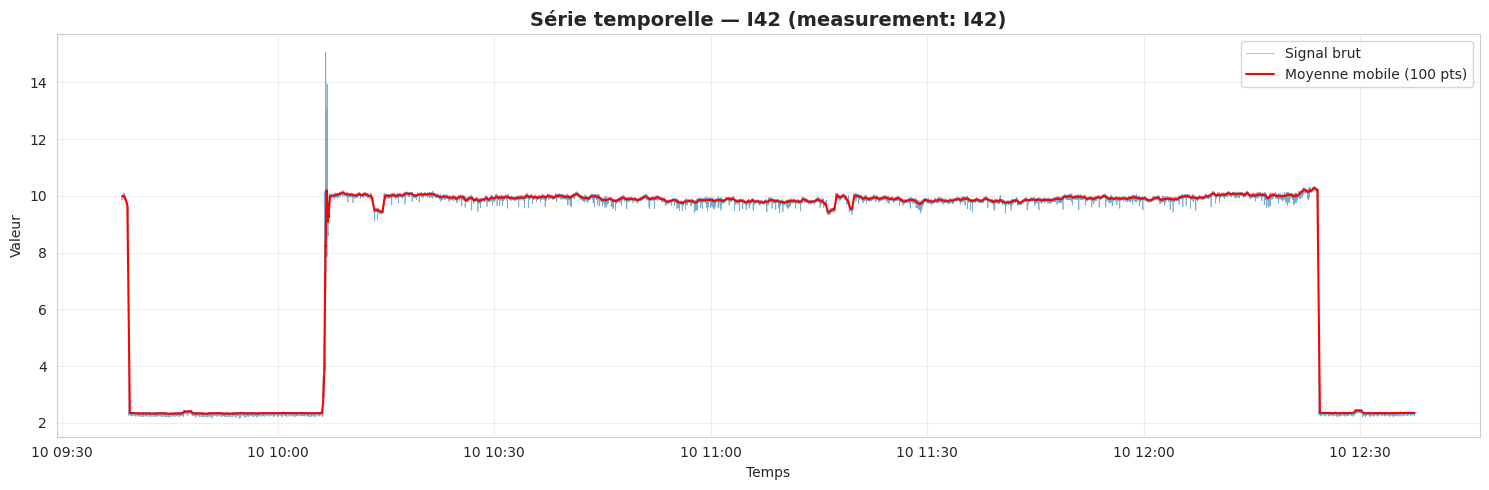

  📈 I42: min=2.1570, max=15.0510, mean=8.1962, std=3.1686
  ⏱️  Période: 2026-03-10 09:38:19.425000+00:00 → 2026-03-10 12:37:41.025000+00:00
  📏 Nombre de points: 53424


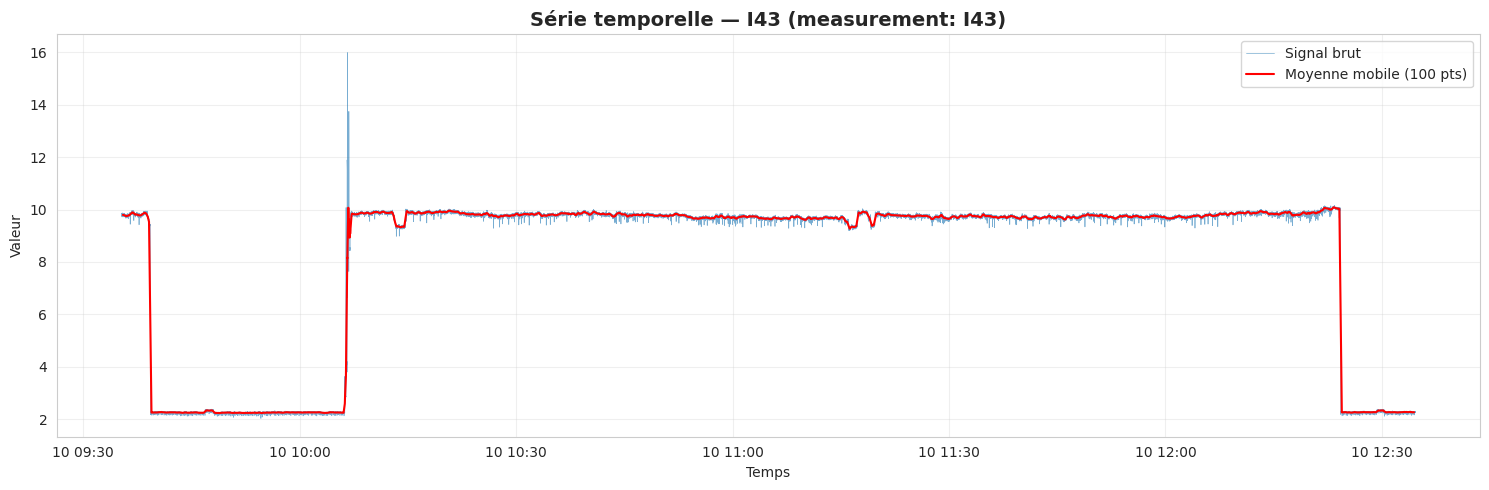

  📈 I43: min=2.0220, max=15.9930, mean=8.1921, std=3.0590
  ⏱️  Période: 2026-03-10 09:35:20.225000+00:00 → 2026-03-10 12:34:38.025000+00:00
  📏 Nombre de points: 53406


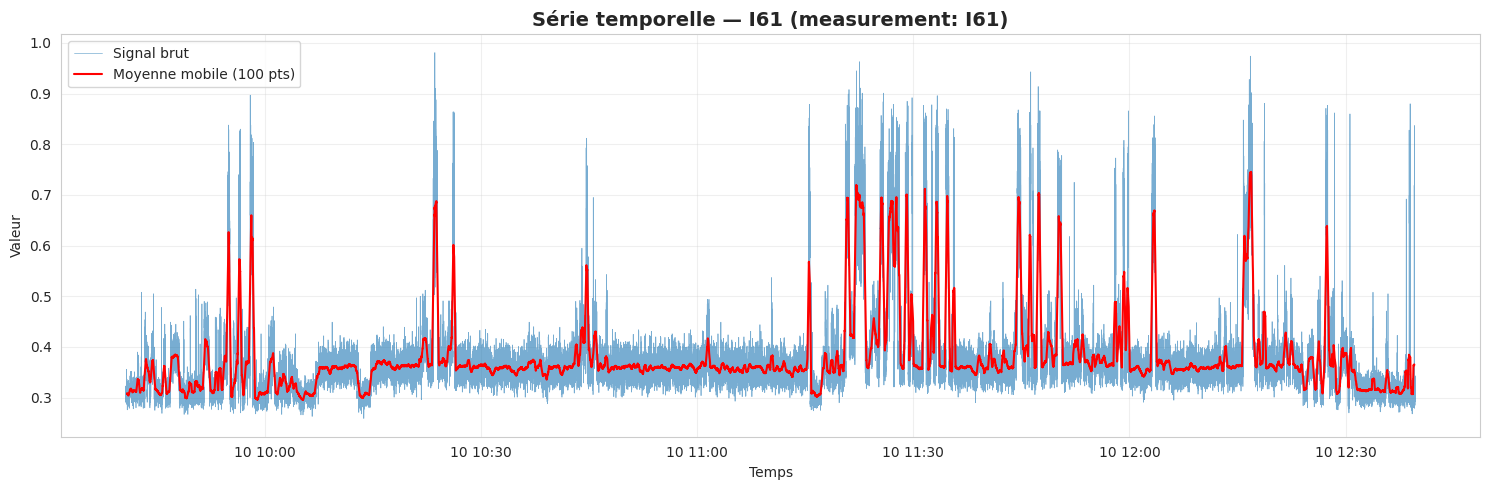

  📈 I61: min=0.2590, max=0.9810, mean=0.3799, std=0.0926
  ⏱️  Période: 2026-03-10 09:40:40.225000+00:00 → 2026-03-10 12:39:43.025000+00:00
  📏 Nombre de points: 53332


In [8]:
# 8.1 — Tracé des séries temporelles avec moyenne mobile
for name, df in dataframes.items():
    if '_time' in df.columns and '_value' in df.columns:
        fig, ax = plt.subplots(figsize=(15, 5))
        
        ax.plot(df['_time'], df['_value'], linewidth=0.5, alpha=0.6, label='Signal brut')
        
        # Moyenne mobile (fenêtre de 100 points)
        window = 100
        rolling_mean = df['_value'].rolling(window=window, center=True).mean()
        ax.plot(df['_time'], rolling_mean, color='red', linewidth=1.5,
                label=f'Moyenne mobile ({window} pts)')
        
        ax.set_title(f'Série temporelle — {name} (measurement: {df["_measurement"].iloc[0]})',
                      fontsize=14, fontweight='bold')
        ax.set_xlabel('Temps')
        ax.set_ylabel('Valeur')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Statistiques
        print(f"  📈 {name}: min={df['_value'].min():.4f}, max={df['_value'].max():.4f}, "
              f"mean={df['_value'].mean():.4f}, std={df['_value'].std():.4f}")
        print(f"  ⏱️  Période: {df['_time'].min()} → {df['_time'].max()}")
        print(f"  📏 Nombre de points: {len(df)}")

🔴 Détection des outliers par IQR (Inter-Quartile Range)



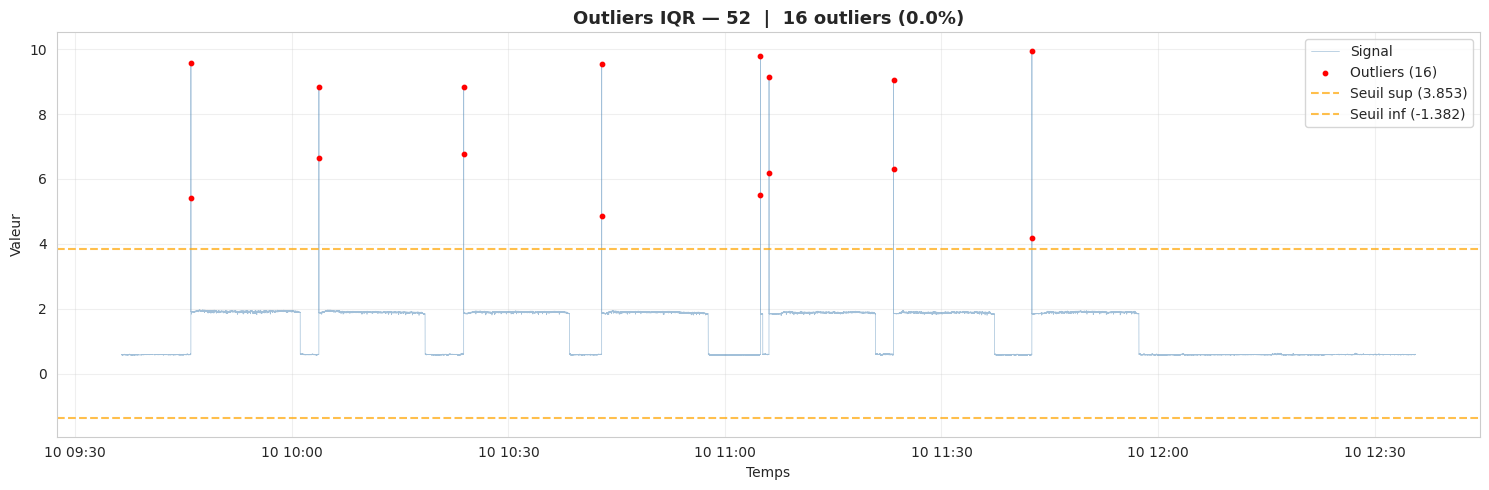

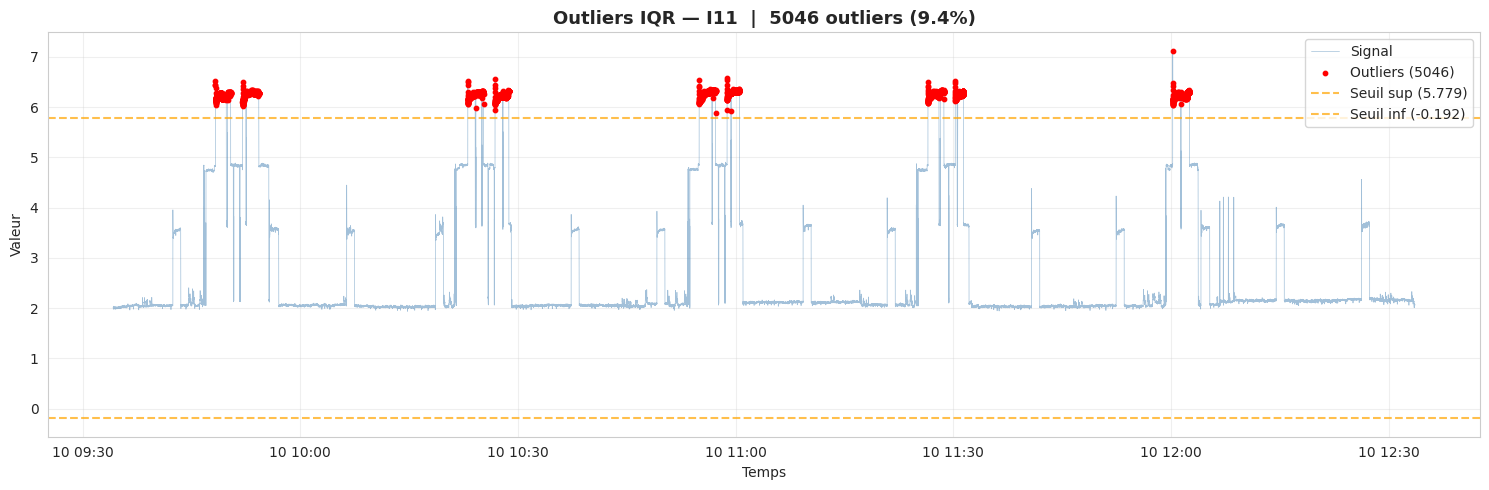

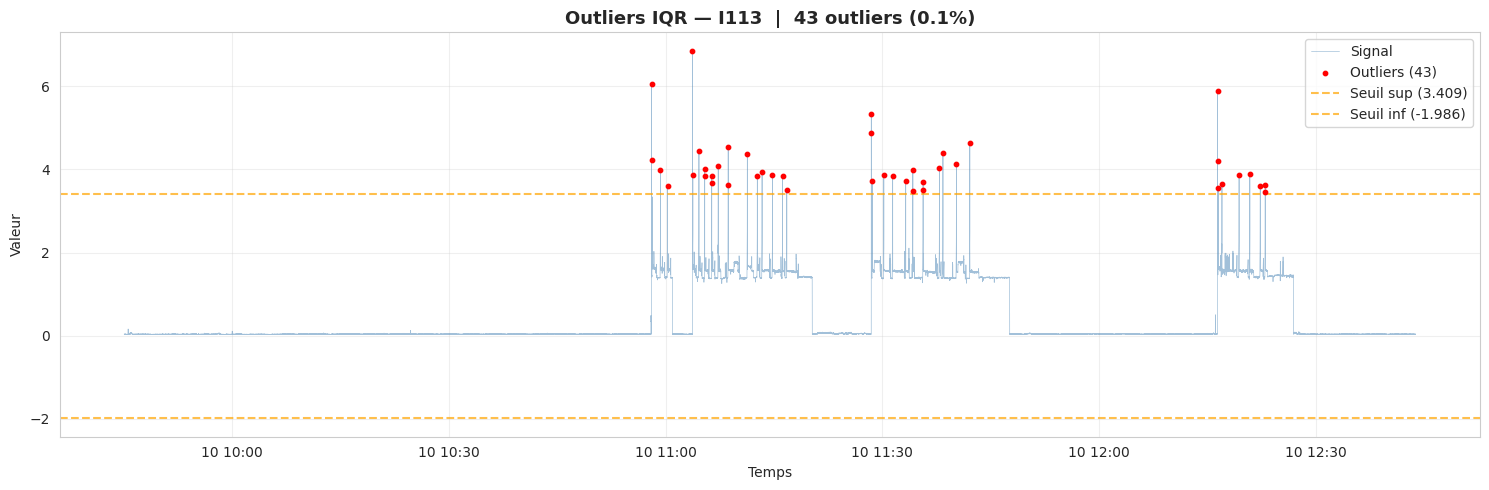

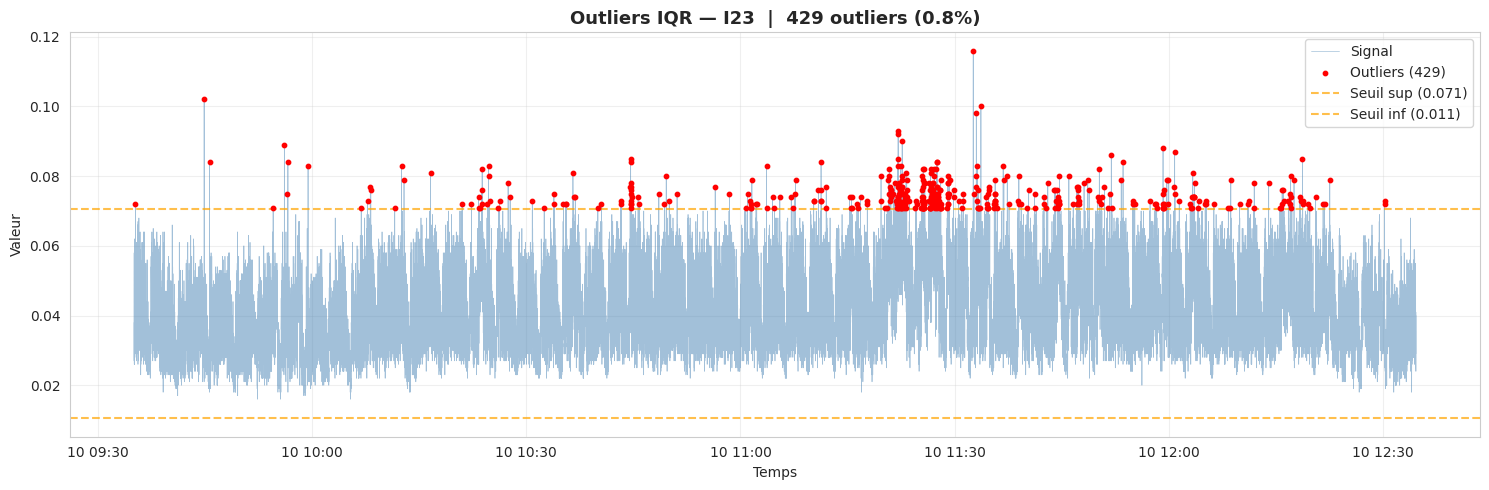

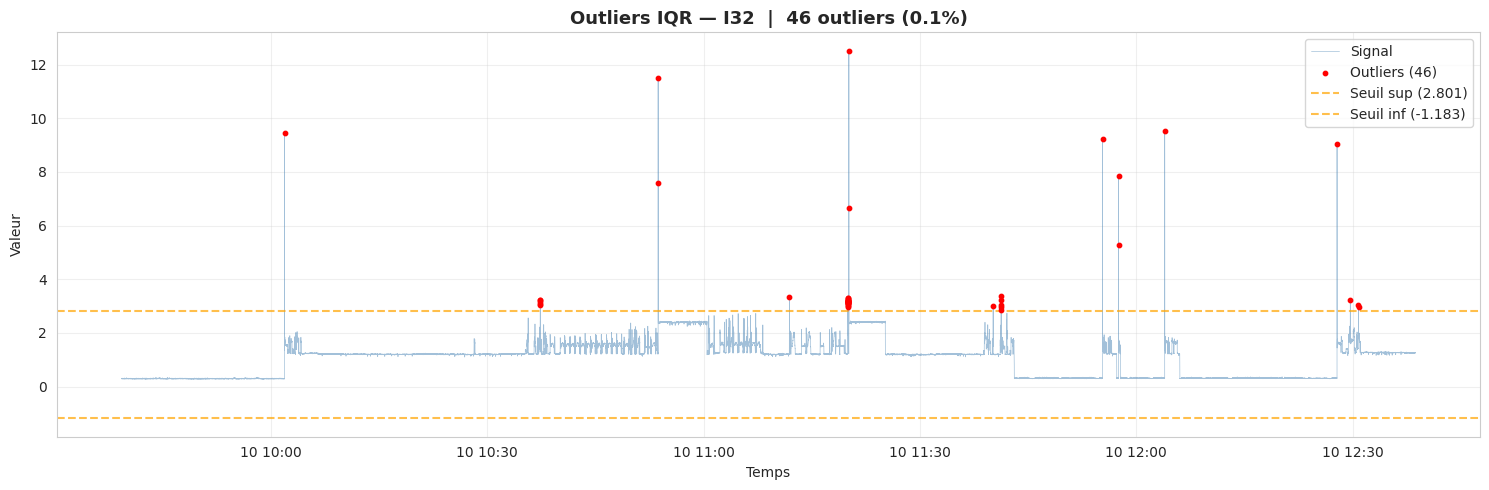

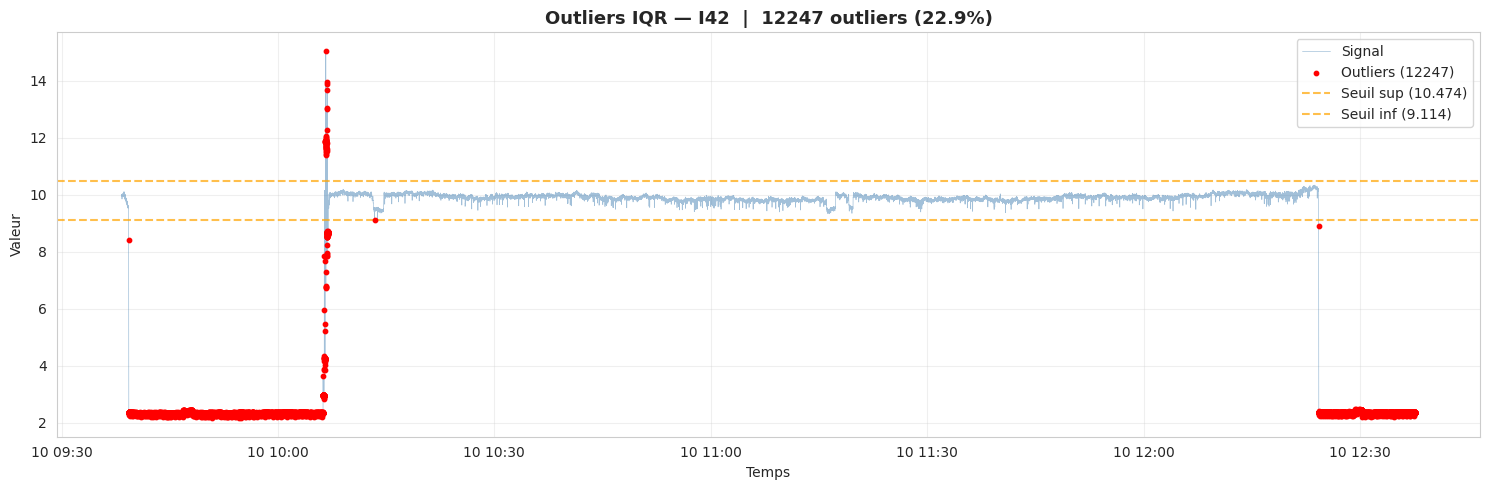

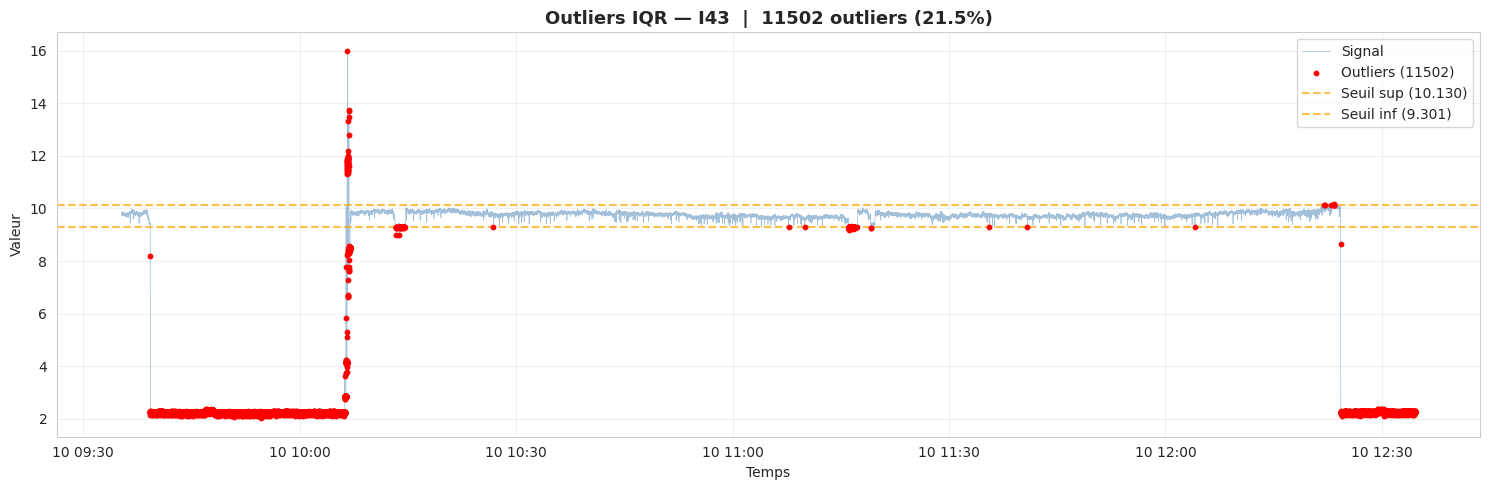

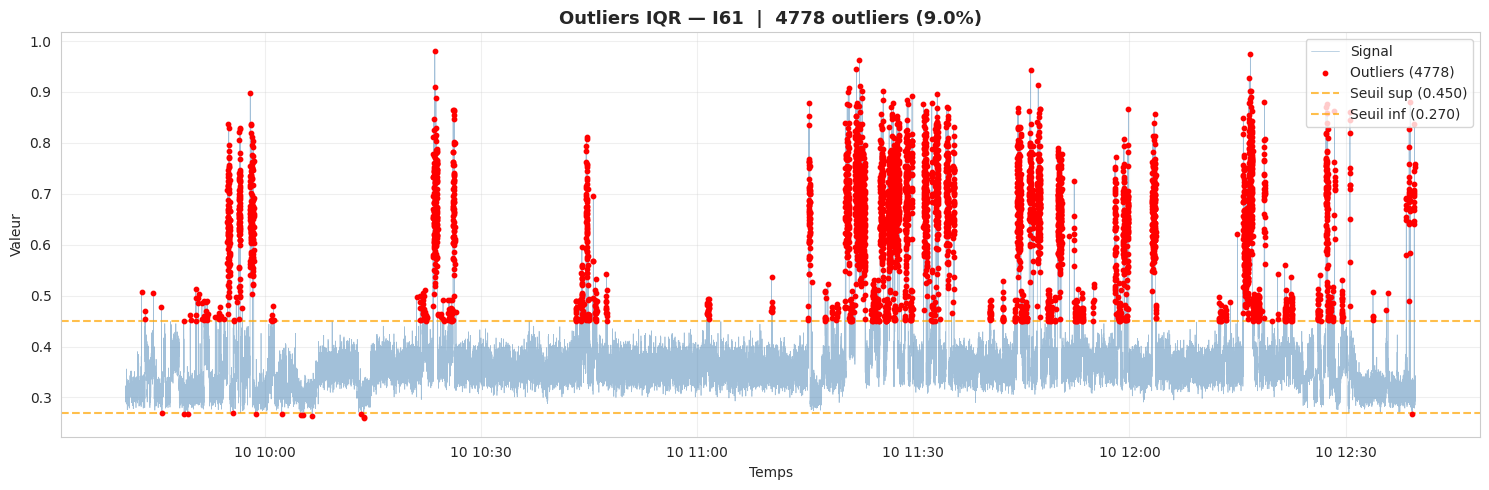


📋 Résumé des outliers par base:
Base        Nb outliers        %    Seuil inf    Seuil sup
----------------------------------------------------------
52                   16     0.0%      -1.3825       3.8535
I11                5046     9.4%      -0.1925       5.7795
I113                 43     0.1%      -1.9865       3.4095
I23                 429     0.8%       0.0105       0.0705
I32                  46     0.1%      -1.1830       2.8010
I42               12247    22.9%       9.1140      10.4740
I43               11502    21.5%       9.3015      10.1295
I61                4778     9.0%       0.2695       0.4495


In [9]:
# 8.2 — Détection des outliers par méthode IQR
print("🔴 Détection des outliers par IQR (Inter-Quartile Range)\n")

outlier_summary = {}

for name, df in dataframes.items():
    if '_time' in df.columns and '_value' in df.columns:
        Q1 = df['_value'].quantile(0.25)
        Q3 = df['_value'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df['_value'] < lower_bound) | (df['_value'] > upper_bound)]
        pct_outliers = len(outliers) / len(df) * 100
        outlier_summary[name] = {
            'count': len(outliers),
            'pct': pct_outliers,
            'lower': lower_bound,
            'upper': upper_bound
        }
        
        # Graphique avec outliers marqués
        fig, ax = plt.subplots(figsize=(15, 5))
        ax.plot(df['_time'], df['_value'], linewidth=0.5, alpha=0.5, color='steelblue', label='Signal')
        
        if len(outliers) > 0:
            ax.scatter(outliers['_time'], outliers['_value'], color='red', s=10,
                       zorder=5, label=f'Outliers ({len(outliers)})')
        
        ax.axhline(y=upper_bound, color='orange', linestyle='--', alpha=0.7, label=f'Seuil sup ({upper_bound:.3f})')
        ax.axhline(y=lower_bound, color='orange', linestyle='--', alpha=0.7, label=f'Seuil inf ({lower_bound:.3f})')
        
        ax.set_title(f'Outliers IQR — {name}  |  {len(outliers)} outliers ({pct_outliers:.1f}%)',
                      fontsize=13, fontweight='bold')
        ax.set_xlabel('Temps')
        ax.set_ylabel('Valeur')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# Tableau récapitulatif
print("\n📋 Résumé des outliers par base:")
print(f"{'Base':<10} {'Nb outliers':>12} {'%':>8} {'Seuil inf':>12} {'Seuil sup':>12}")
print("-" * 58)
for name, info in outlier_summary.items():
    print(f"{name:<10} {info['count']:>12} {info['pct']:>7.1f}% {info['lower']:>12.4f} {info['upper']:>12.4f}")

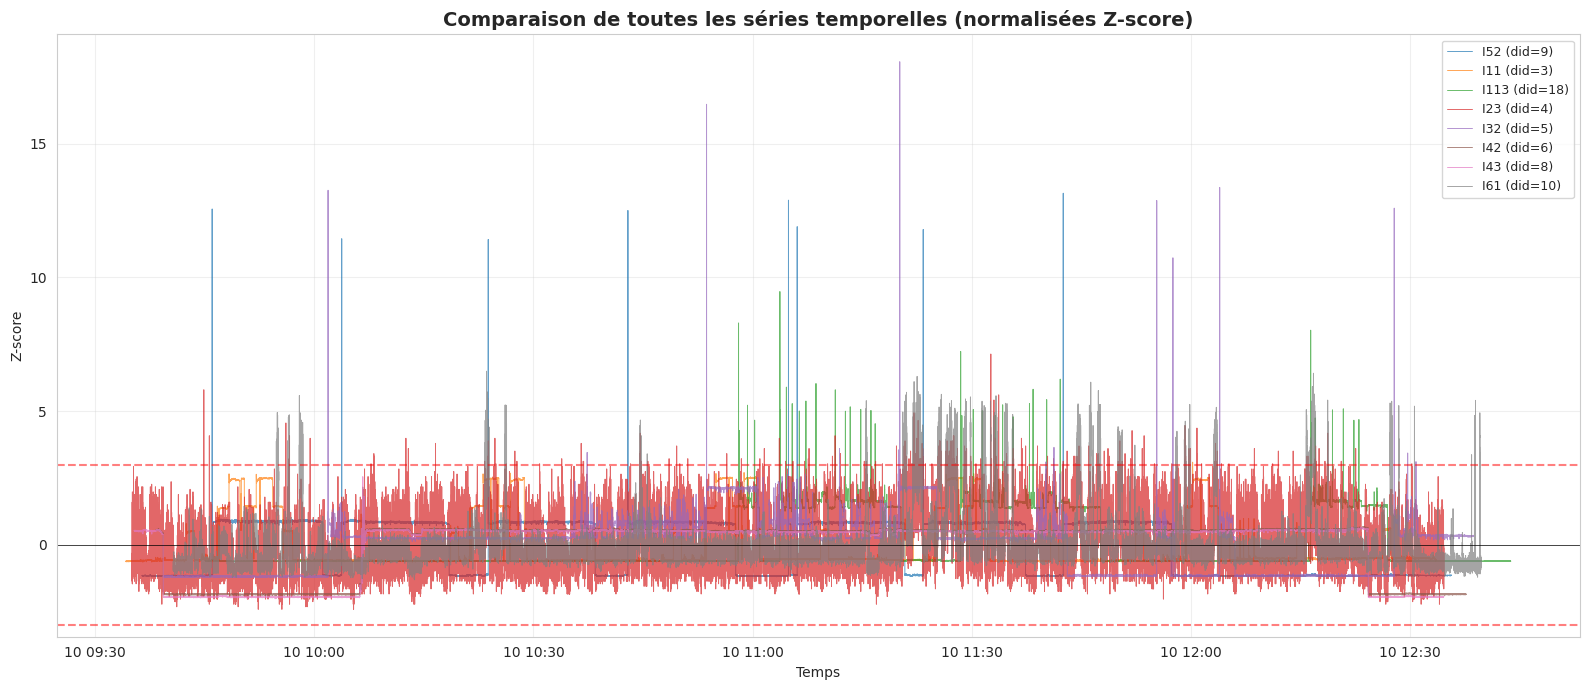

In [10]:
# 8.3 — Comparaison de toutes les séries normalisées (Z-score)
fig, ax = plt.subplots(figsize=(16, 7))

for name, df in dataframes.items():
    if '_time' in df.columns and '_value' in df.columns:
        # Normalisation Z-score pour comparer les séries sur la même échelle
        mean_val = df['_value'].mean()
        std_val = df['_value'].std()
        z_score = (df['_value'] - mean_val) / std_val
        
        measurement = df['_measurement'].iloc[0] if '_measurement' in df.columns else name
        ax.plot(df['_time'], z_score, linewidth=0.7, alpha=0.7, label=f'{measurement} (did={df["did"].iloc[0]})')

ax.set_title('Comparaison de toutes les séries temporelles (normalisées Z-score)', fontsize=14, fontweight='bold')
ax.set_xlabel('Temps')
ax.set_ylabel('Z-score')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='±3σ')
ax.axhline(y=-3, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 📊 8.4 — Interprétation détaillée des résultats

---

#### A) Ce que montrent les graphiques de séries temporelles (8.1)

**I52 (did=9)** — Le signal oscille entre **~0.6A** (repos) et **~1.9A** (actif) avec des **pics très brefs à ~10A**. C'est un équipement qui alterne entre 2 niveaux avec de rares appels de courant extrêmes (probablement un démarrage moteur).

**I11 (did=3)** — Signal complexe avec **plusieurs niveaux** : repos à ~2A, montées à ~3.5A, ~4.8A et ~6.3A. Les transitions sont fréquentes et cycliques (~30 min). C'est un équipement industriel avec **plusieurs modes de fonctionnement**.

**I113 (did=18)** — Quasi-éteint pendant la 1ère heure (~0.03A), puis **s'active vers 10h45** avec un courant de ~1.5-1.7A et des pics à ~4-7A. Deux phases d'activité distinctes.

**I23 (did=4)** — Signal très faible (0.02–0.12A) et **bruité**. C'est du bruit de mesure autour de 0.04A. Probablement un circuit en **veille** ou un capteur de courant de fuite.

**I32 (did=5)** — Signal avec **paliers multiples** (0.3A, 1.3A, 1.8A, 2.5A) et des **pics extrêmes** très brefs (9.5A, 11.5A, 12.5A). Équipement complexe avec plusieurs niveaux de puissance.

**I42 (did=6)** — Pattern **ON/OFF très clair** : début à ~10A, chute à ~2.4A (09:45–10:05), puis remonte et reste stable à ~10A. Pic de transition à ~15A au redémarrage. Un seul cycle OFF/ON sur 3h.

**I43 (did=8)** — **Quasi-identique à I42** : même pattern ON/OFF aux mêmes moments. Les deux capteurs surveillent probablement le **même équipement** ou deux équipements synchronisés.

**I61 (did=10)** — Signal de base à ~0.33A avec beaucoup de **micro-pics** (0.5–0.98A). Les pics deviennent plus fréquents et intenses après 11h. Possible surcharge progressive ou perturbation.

---

#### B) Ce que montrent les distributions (Section 7)

Les histogrammes confirment les profils :
- **I42 et I43** → distribution **bimodale** (2 pics : un à ~2.4A et un à ~10A)
- **I52, I113, I32** → distribution **asymétrique** avec un pic principal à gauche et une longue queue vers la droite (pics rares mais intenses)
- **I23** → distribution **quasi-gaussienne** centrée sur 0.04A (bruit symétrique)
- **I61** → distribution **asymétrique à droite** (la majorité à ~0.34A avec une queue vers 1A)

Le boxplot comparatif montre que **I42 et I43 ont les courants les plus élevés** (~10A), tandis que **I23 est quasi-invisible** (~0.04A).

---

#### C) Ce que montrent les outliers IQR (8.2)

| Capteur | Nb outliers | % du total | Ce que ça veut dire |
|---------|-------------|------------|---------------------|
| **I52** | 16 | 0.0% | Seulement les pics brefs à ~10A → **vrais outliers**, anomalies potentielles |
| **I11** | 5 046 | **9.4%** | Les phases hautes (>5.8A) → ce sont les modes "haute puissance", **pas des anomalies** |
| **I113** | 43 | 0.1% | Les pics > 3.4A pendant les phases actives → **candidats anomalies** |
| **I23** | 429 | 0.8% | Les valeurs > 0.07A → bruit un peu fort, **peu significatif** |
| **I32** | 46 | 0.1% | Les pics extrêmes > 2.8A → **vrais outliers à investiguer** |
| **I42** | 12 247 | **22.9%** | ⚠️ L'IQR considère les phases OFF (~2.4A) + le pic (15A) comme outliers → **FAUX POSITIFS**, c'est le comportement normal ON/OFF |
| **I43** | 11 502 | **21.5%** | ⚠️ Même problème que I42 → l'IQR ne convient pas pour un signal bimodal |
| **I61** | 4 778 | **9.0%** | Les pics > 0.45A → pourraient être des **perturbations réelles** à surveiller |

**Conclusion sur l'IQR** : cette méthode fonctionne bien pour I52, I113, I32, I23 (distributions unimodales). Elle est **inadaptée pour I42, I43** (bimodale) et **discutable pour I11, I61** (multi-niveaux).

---

#### D) Ce que montre le graphique Z-score comparatif (8.3)

Le graphique normalisé montre que :
- **I52 et I32** ont les pics Z-score les plus extrêmes (>10σ) → les anomalies les plus violentes par rapport à leur bruit de fond
- **I23** reste dans le bruit (Z-score rarement > 3)
- Plusieurs capteurs ont des pics **simultanés** autour de 10h00 → possible événement commun (perturbation électrique ?)

---

#### E) Résumé — 3 profils de capteurs identifiés

**Profil 1 — Signal stable avec bruit** : `I23`, `I61`
- Courant faible et constant, idéal pour détection par seuil simple (Z-score > 3)

**Profil 2 — Signal ON/OFF (bimodal)** : `I42`, `I43`
- Alternance entre 2 niveaux → analyser les **durées des phases** plutôt que les valeurs brutes

**Profil 3 — Signal avec paliers et pics** : `I52`, `I11`, `I113`, `I32`
- Transitions entre plusieurs niveaux + pics brefs → utiliser **Isolation Forest** ou **LSTM Autoencoder**

---

#### F) Recommandations pour la détection d'anomalies

1. **Pré-traitement** : garder uniquement `_time`, `_value`, `_measurement`, `did`
2. **Ne pas utiliser la même méthode pour tous les capteurs** — adapter selon le profil
3. **I42/I43** → détecter les anomalies sur la **durée des phases ON/OFF** (une phase OFF trop longue = anomalie)
4. **I23/I61** → **Z-score** ou **seuil statistique** (simple et efficace)
5. **I52/I113/I32** → **Isolation Forest** pour les pics anormaux
6. **I11** → analyser la **fréquence et régularité des cycles** (un cycle manqué ou décalé = anomalie)